### Imports

In [1]:
import sys
mypath = "/home/basia/Documents/spectroscopy/magnetstein"
sys.path.insert(0, mypath)

In [2]:
import sys
import numpy as np
import pandas as pd
import os
from masserstein import NMRSpectrum, estimate_proportions
import matplotlib.pyplot as plt
import pulp
import pickle
import time

### Data

In [3]:
experiment_name = 'PMG 287 monitoring with separable peaks'

In [4]:
mixture_paths = {
                'Saccharose hydrolysis': '../data/saccharose_hydrolysis/preprocessed_mixture.csv',
                'PMG 284 monitoring': '../data/PMG_284/preprocessed_mixture.csv',
                'PMG 287 monitoring': '../data/PMG_287/preprocessed_mixture_cut_to_regions.csv',
                'Saccharose hydrolysis with full mixture spectrum': '../data/saccharose_hydrolysis_full_mixture_spectrum/preprocessed_mixture.csv',
                'PMG 284 monitoring with full mixture spectrum': '../data/PMG_284_full_mixture_spectrum/preprocessed_mixture_whole.csv',
                'PMG 287 monitoring with full mixture spectrum': '../data/PMG_287_full_mixture_spectrum/preprocessed_mixture_whole.csv',
                'PMG 287 monitoring with separable peaks': '../data/PMG_287_separable_peaks/preprocessed_mixture_separable_peaks.csv'
                }

reagents_paths = {
                'Saccharose hydrolysis': ['../data/saccharose_hydrolysis/preprocessed_saccharose.csv', 
                                            '../data/saccharose_hydrolysis/preprocessed_alpha_glucose.csv',
                                            '../data/saccharose_hydrolysis/preprocessed_beta_glucose.csv',
                                            '../data/saccharose_hydrolysis/preprocessed_fructose.csv'],
                'PMG 284 monitoring': ['../data/PMG_284/preprocessed_pentene.csv',
                                      '../data/PMG_284/preprocessed_triethylsilane.csv',
                                      '../data/PMG_284/preprocessed_product.csv'],
                'PMG 287 monitoring': ['../data/PMG_287/preprocessed_hexene.csv',
                                      '../data/PMG_287/preprocessed_triethylsilane.csv',
                                      '../data/PMG_287/preprocessed_product.csv'],
                'Saccharose hydrolysis with full mixture spectrum': [
                                            '../data/saccharose_hydrolysis_full_mixture_spectrum/preprocessed_saccharose.csv', 
                                            '../data/saccharose_hydrolysis_full_mixture_spectrum/preprocessed_alpha_glucose.csv',
                                            '../data/saccharose_hydrolysis_full_mixture_spectrum/preprocessed_beta_glucose.csv',
                                            '../data/saccharose_hydrolysis_full_mixture_spectrum/preprocessed_fructose.csv'],
                'PMG 284 monitoring with full mixture spectrum' : ['../data/PMG_284_full_mixture_spectrum/preprocessed_pentene.csv',
                                                                  '../data/PMG_284_full_mixture_spectrum/preprocessed_triethylsilane.csv',
                                                                  '../data/PMG_284_full_mixture_spectrum/preprocessed_product.csv'],
    
                'PMG 287 monitoring with full mixture spectrum': ['../data/PMG_287_full_mixture_spectrum/preprocessed_hexene.csv',
                                                                  '../data/PMG_287_full_mixture_spectrum/preprocessed_triethylsilane.csv',
                                                                  '../data/PMG_287_full_mixture_spectrum/preprocessed_product.csv'],
                'PMG 287 monitoring with separable peaks': ['../data/PMG_287_separable_peaks/preprocessed_hexene.csv',
                                                           '../data/PMG_287_separable_peaks/preprocessed_triethylsilane.csv']

}

mixture_separators = {
                        'Saccharose hydrolysis': '\t',
                        'PMG 284 monitoring': '\t',
                        'PMG 287 monitoring': '\t',
                        'Saccharose hydrolysis with full mixture spectrum': '\t',
                        'PMG 284 monitoring with full mixture spectrum': '\t',
                        'PMG 287 monitoring with full mixture spectrum': '\t',
                        'PMG 287 monitoring with separable peaks': '\t'

                        }

reagents_separators = {
                'Saccharose hydrolysis': '\t',
                'PMG 284 monitoring': '\t',
                'PMG 287 monitoring': '\t',
                'Saccharose hydrolysis with full mixture spectrum': '\t',
                'PMG 284 monitoring with full mixture spectrum': '\t',
                'PMG 287 monitoring with full mixture spectrum': '\t',
                'PMG 287 monitoring with separable peaks': '\t'
                }

results_paths = {
                'Saccharose hydrolysis': '../results/saccharose_hydrolysis/',
                'PMG 284 monitoring': '../results/PMG_284/',
                'PMG 287 monitoring': '../results/PMG_287/',
                'Saccharose hydrolysis with full mixture spectrum': '../results/saccharose_hydrolysis_full_mixture_spectrum/',
                'PMG 284 monitoring with full mixture spectrum': '../results/PMG_284_full_mixture_spectrum/',
                'PMG 287 monitoring with full mixture spectrum': '../results/PMG_287_full_mixture_spectrum/',
                'PMG 287 monitoring with separable peaks': '../results/PMG_287_separable_peaks/'
                }

#### Mixture in time

In [5]:
mixture_time_data = pd.read_csv(mixture_paths[experiment_name], sep = mixture_separators[experiment_name])
if experiment_name == 'Saccharose hydrolysis' or experiment_name == 'Saccharose hydrolysis with full mixture spectrum':
    ppm = mixture_time_data.iloc[:,0:1]
    every_10th = mixture_time_data.iloc[:,1:].iloc[:,::10]
    mixture_time_data = pd.concat((ppm, every_10th), axis=1)
elif experiment_name == 'PMG 284 monitoring' or experiment_name == 'PMG 284 monitoring with full mixture spectrum':
    ppm = mixture_time_data.iloc[:,:-1].iloc[:,0:1]
    every_10th = mixture_time_data.iloc[:,:-1].iloc[:,1:].iloc[:,::10]
    mixture_time_data = pd.concat((ppm, every_10th), axis=1)
elif experiment_name == 'PMG 287 monitoring' or experiment_name == 'PMG 287 monitoring with full mixture spectrum' or experiment_name == 'PMG 287 monitoring with separable peaks':
    ppm = mixture_time_data.iloc[:,:-1].iloc[:,0:1]
    every_10th = mixture_time_data.iloc[:,:-1].iloc[:,1:].iloc[:,::10]
    mixture_time_data = pd.concat((ppm, every_10th), axis=1)

In [6]:
names = ['ppm'] + ['t' + str(nb) for nb in range(1, mixture_time_data.shape[1])]

In [7]:
mixture_time_data.columns = names

In [8]:
def load_spectrum(mixture_time_data, moment_of_time):
    ppm = mixture_time_data['ppm']
    intensity = mixture_time_data['t'+str(moment_of_time)]
    sp = NMRSpectrum(confs = list(zip(ppm, intensity)))
    sp.trim_negative_intensities()
    sp.normalize()
    return sp

#### Reagents

In [9]:
reagents_spectra = []
for reagent in reagents_paths[experiment_name]:
    reag = pd.read_csv(reagent, sep=reagents_separators[experiment_name], header=None).iloc[:,:2]
    reagents_spectra.append(reag)

In [10]:
reagents_spectra2 = []
for reag in reagents_spectra:
    ppm = reag.iloc[:,0]
    ints = reag.iloc[:,1]
    sp = NMRSpectrum(confs = list(zip(ppm, ints)))
    reagents_spectra2.append(sp)
reagents_spectra = reagents_spectra2
del(reagents_spectra2)

In [11]:
for sp in reagents_spectra:
    sp.trim_negative_intensities()
    sp.normalize()

In [12]:
reagents_spectra

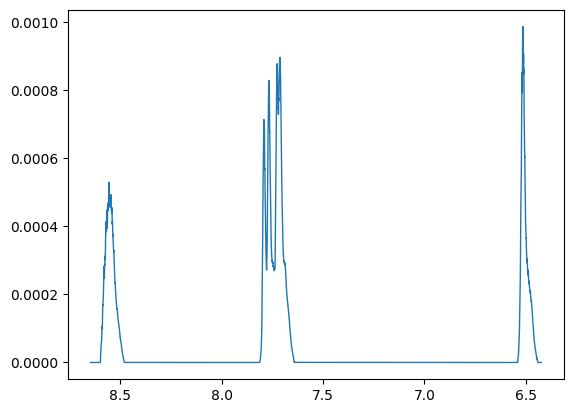

In [13]:
plt.gca().invert_xaxis()
NMRSpectrum.plot(load_spectrum(mixture_time_data, 30), profile=True)
#NMRSpectrum.plot_all(reagents_spectra + [load_spectrum(mixture_time_data, 100)], profile=True)

### Estimation

In [14]:
kappa = 0.5
kappa_th = 0.5

In [15]:
proportions_in_times = []
noise_proportions_in_times = []
noise = []
noise_in_components = []

start_time = time.time()

for i in range(1, mixture_time_data.shape[1]):
    print('This is timepoint '+str(i)+'.\n')
    mix = load_spectrum(mixture_time_data, i)
    mix.trim_negative_intensities()
    mix.normalize()
    estimation = estimate_proportions(mix, reagents_spectra, what_to_compare='area', 
                                      solver=pulp.GUROBI(msg=False),
                                     MTD=kappa, MTD_th=kappa_th)
    proportions_in_times.append(estimation['proportions'])
    noise_proportions_in_times.append(estimation['proportion_of_noise_in_components'])
    noise.append(estimation['noise'])
    noise_in_components.append(estimation['noise_in_components'])
#     if i>1:
#         assert estimation['common_horizontal_axis'] == common_horizontal_axis
    common_horizontal_axis = estimation['common_horizontal_axis']
    
    print('Proportions:\n')
    print(estimation['proportions'])
    print('\n')
    print('Proportion_of_noise_in_components:\n')
    print(estimation['proportion_of_noise_in_components'])
    print('\n')

end_time = time.time()

This is timepoint 1.

Set parameter Username
Academic license - for non-commercial use only - expires 2025-12-20


/home/basia/myvirtualenv/lib/python3.12/site-packages/pulp/pulp.py:1316: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")


Proportions:

[0.761256351682758, 0.238743648317242]


Proportion_of_noise_in_components:

0.0


This is timepoint 2.



/home/basia/Documents/spectroscopy/magnetstein/masserstein/deconv_simplex.py:550: UserWarning: In dualdeconv4:
                Proportions of signal and noise sum to 9.585351 instead of 1.
                This may indicate improper results.
                Please check the deconvolution results and consider reporting this warning to the authors.
                                    
  warn("""In dualdeconv4:
/home/basia/Documents/spectroscopy/magnetstein/masserstein/deconv_simplex.py:868: UserWarning: In estimate_proportions:
Proportions of signal and noise sum to 7.602889 instead of 1.
This may indicate improper results.
Please check the deconvolution results and consider reporting this warning to the authors.
                        
  warn("""In estimate_proportions:


Proportions:

[0.7690878045005615, 0.2309121954994386]


Proportion_of_noise_in_components:

0.0


This is timepoint 3.



...

Proportions:

[0.7622799166287022, 0.23772008337129774]


Proportion_of_noise_in_components:

0.0


This is timepoint 37.



/home/basia/Documents/spectroscopy/magnetstein/masserstein/deconv_simplex.py:550: UserWarning: In dualdeconv4:
                Proportions of signal and noise sum to 6.438730 instead of 1.
                This may indicate improper results.
                Please check the deconvolution results and consider reporting this warning to the authors.
                                    
  warn("""In dualdeconv4:


Proportions:

[0.7614817026198027, 0.23851829738019728]


Proportion_of_noise_in_components:

0.0


This is timepoint 38.



/home/basia/Documents/spectroscopy/magnetstein/masserstein/deconv_simplex.py:550: UserWarning: In dualdeconv4:
                Proportions of signal and noise sum to 5.013966 instead of 1.
                This may indicate improper results.
                Please check the deconvolution results and consider reporting this warning to the authors.
                                    
  warn("""In dualdeconv4:


Proportions:

[0.7607639564517525, 0.23923604354824762]


Proportion_of_noise_in_components:

0.0


This is timepoint 39.

Proportions:

[0.7594985710066774, 0.24050142899332264]


Proportion_of_noise_in_components:

0.0


This is timepoint 40.

Proportions:

[0.7584776329752246, 0.24152236702477542]


Proportion_of_noise_in_components:

0.0


This is timepoint 41.

Proportions:

[0.7606835731314605, 0.23931642686853946]


Proportion_of_noise_in_components:

0.0


This is timepoint 42.

Proportions:

[0.7611313892195829, 0.23886861078041702]


Proportion_of_noise_in_components:

0.0


This is timepoint 43.

Proportions:

[0.762568739648072, 0.23743126035192813]


Proportion_of_noise_in_components:

0.0


This is timepoint 44.

Proportions:

[0.7676883862736141, 0.2323116137263858]


Proportion_of_noise_in_components:

0.0


This is timepoint 45.

Proportions:

[0.7736385750151787, 0.22636142498482126]


Proportion_of_noise_in_components:

0.0


This is timepoint 46.

Proportions:

[0.7

In [16]:
len(proportions_in_times)

100

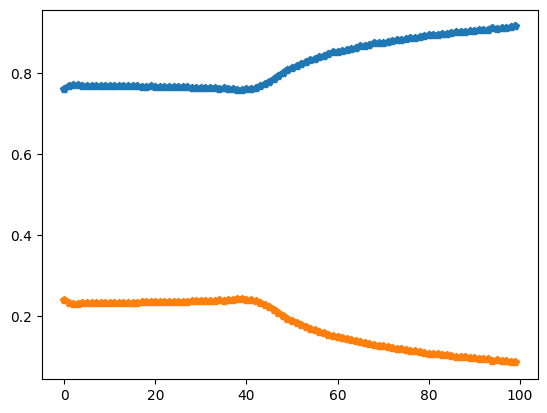

In [17]:
for i in range(len(reagents_spectra)):
    plt.plot(range(len(proportions_in_times)), [prop[i] for prop in proportions_in_times], 'p')

In [20]:
with open(results_paths[experiment_name]+'proportions_in_times_'+str(kappa)+'_'+str(kappa_th)+'.pkl', 'wb') as f:
    pickle.dump(proportions_in_times, f)

In [21]:
with open(results_paths[experiment_name]+'noise_proportions_in_times_'+str(kappa)+'_'+str(kappa_th)+'.pkl', 'wb') as f:
    pickle.dump(noise_proportions_in_times, f)

In [22]:
with open(results_paths[experiment_name]+'common_horizontal_axis_'+str(kappa)+'_'+str(kappa_th)+'.pkl', 'wb') as f:
    pickle.dump(common_horizontal_axis, f)

In [23]:
with open(results_paths[experiment_name]+'noise_'+str(kappa)+'_'+str(kappa_th)+'.pkl', 'wb') as f:
    pickle.dump(noise, f)

In [24]:
with open(results_paths[experiment_name]+'noise_in_components_'+str(kappa)+'_'+str(kappa_th)+'.pkl', 'wb') as f:
    pickle.dump(noise_in_components, f)